- PROJETO RISCO DE CREDITO

In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')

In [ ]:
df

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df[df['person_age']>80].count()

In [ ]:
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

--TRATAMENTO DE OUTLIERS


In [ ]:
# TRATANDO OS CLIENTES COM IDADE MAIOR QUE 90 ANOS
df.loc[df['person_age']>90]

In [ ]:
# APAGANDO REGISTROS INCONSISTENTES
# CRIEI UM NOVO DATAFRAME RECEBENDO O DATAFRAME, APAGANDO AS LINHAS CO IDADE > 90 ANOS

df2=df.drop(df[df['person_age']>90].index)
df2

In [10]:
# Vamos verificar se ainda existem pessoas com idade maior que 90 anos na base?
df2[df2["person_age"]>90]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [11]:
# Nenhum registro encontrado

In [12]:
# Verificamos um segundo outlieis em Person_emo_length, que seria tempo de emprego (anos)
# 120 anos de trabalho?  quem seria esse ser humano? 
# para nosso estudo, iremos considerar apenas pessoas com até 40 anos de emprego


In [ ]:
df2[df2['person_emp_length']>40]

In [14]:
df3=df2.drop(df2[df2['person_emp_length']>40].index)


In [15]:
df3[df3['person_emp_length']>40]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [ ]:
df[df['person_emp_length']>20].count()


- APÓS TRATAR ESSAS VARIAVEIS, IREMOS SEPARAS OS PREVISORES DA CLASSE.

CLASE É NOSSO ALVO. OQUE QUEREMOS, ONDE QUEREMOS CHEGAR COM O ESTUDO. EM NOSSO CASO, SABER SE UMA PESSOA IRÁ PAGAR OU NÃO UM EMPRESTIMO

PREVISORES - AS VARIAVES QUE NOS FAZ TOMAR ESSA DECISÃO. É A NOSSA BASE....

In [ ]:
# SEPARANDO OS PREVISORES DA CLASSE
# NOS ESTUDS É COMUM UTILIZAROS A VARIAVEL X COMO PREVISOR E Y COMO CLASSE
# LEMBRANDO QUE 0 É O BOM PAGADOR E 1 INADIMPLENTE


Y = df3.loc[X.index, 'loan_status']
Y.head()



In [ ]:
# SEPARANDO OS PREVISORES. PARA A UTILIZAÇÃO DO KNN É IMPORTANTE SELECIONAR OS PREVISORES DE FORMA CLARE E OBJETIVA. 
# UTILIZAR O KNN COM UMA QUANTIDADE MUITO GRANDE DE PREVISORE, PODE CONFUNDIR O ALGORITMO
# Utilizaremos loan_percent_income, quanto da renda irá para o emprestimo
# cb_person_default_on_file, se o cliente possui historico de inadimplencia
# loan_int_rate, taxa de juros
# person income, renda do cliente


X=df3[['loan_percent_income','cb_person_default_on_file','loan_int_rate','person_income']]
X.head()

In [89]:
# PARA TRABALHAR COM KN É PRECISO TAMBEM FAZER OUTROS TRATAMENTOS COMO TRANSFORMAR COLUNAS CATEGORICAS EM NUMERICAS.
# IREMOS FAZER ISSO COM A COLUNA CB_PERSON QUE NESSE MOMENTO É UMa string

X['cb_person_default_on_file'] = X['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

X.info()

<class 'pandas.DataFrame'>
Index: 32572 entries, 1 to 32580
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   loan_percent_income        32572 non-null  float64
 1   cb_person_default_on_file  32572 non-null  int64  
 2   loan_int_rate              29458 non-null  float64
 3   person_income              32572 non-null  int64  
dtypes: float64(2), int64(2)
memory usage: 1.2 MB


In [87]:
# AGORA O N SERÁ REPRESENTADO POR 0 E Y POR 1

X.head()

,loan_percent_income,cb_person_default_on_file,loan_int_rate,person_income
1,0.10,N,11.14,9600
2,0.57,N,12.87,9600
3,0.53,N,15.23,65500
4,0.55,Y,14.27,54400
5,0.25,N,7.14,9900


-“Foi necessário normalizar os dados, pois o algoritmo KNN é baseado em distância e sensível à escala das variáveis. Além disso, variáveis categóricas foram convertidas para formato numérico para permitir o processamento pelo modelo.”


In [128]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [129]:
# Imputação: substitui NaN pela média
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Criando o modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Treinando
knn.fit(X_train, y_train)

# Fazendo previsões
y_pred = knn.predict(X_test)

# Avaliando o desempenho
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Relatório de classificação:\n", classification_report(y_test, y_pred))


- Seu modelo KNN para risco de crédito alcançou uma acurácia de ~83,7%, com ótimo desempenho para clientes de baixo risco (classe 0), mas ainda com espaço para melhorar na identificação de clientes de alto risco (classe 1). Os gráficos de matriz de confusão e curva ROC ajudam a visualizar esses resultados.

Resultados do Modelo
Acurácia geral: 83,7%

Classe 0 (baixo risco):

Precision: 0,87

Recall: 0,93

F1-score: 0,90

Classe 1 (alto risco):

Precision: 0,67

Recall: 0,52

F1-score: 0,58

👉 O modelo está muito bom em identificar clientes de baixo risco, mas ainda perde alguns casos de alto risco (recall de 52%).



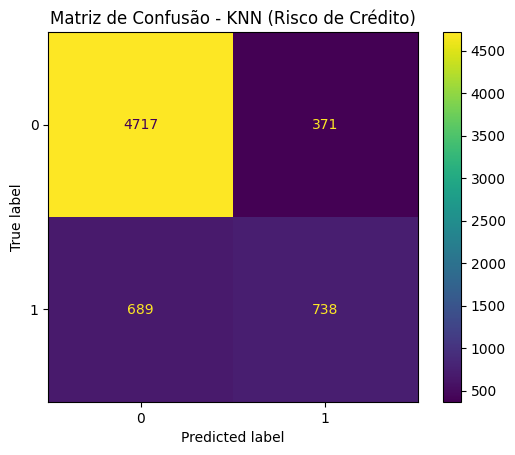

In [131]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusão - KNN (Risco de Crédito)")
plt.show()

-Interpretação (coloque no seu projeto):
Verdadeiros negativos (0 bem classificado): bons pagadores corretos
Verdadeiros positivos (1 bem classificado): inadimplentes corretos
Seu modelo está melhor em prever bons pagadores (classe 0) do que inadimplentes (classe 1)